# Lab: Intro. ANN, MNIST Model + Deploy with Streamlit

- รหัสนิสิต: 67102010164
- ชื่อ - นามสกุล: นรวิชญ์ มากปรางค์

Train a fully connected neural network on MNIST, evaluate unseen test images, save/reload the model, and deploy an image-upload application.

- Google Sheet: https://docs.google.com/spreadsheets/d/1vlqe8af47zth2FBis0wQvH4wshqjyFTkz6NHVKW3Ug4/edit
- GitHub repository: https://github.com/ToonRz/week6-ann-mnist-deploy-67102010164
- MNIST app: DEPLOYMENT_PENDING
- Submission folder: https://drive.google.com/drive/folders/1CUDaaiINvVLtBqnbhTmkeTn7oHqjXgXb


ส่งเป็น link folder week6-ANN-MNIST-Deploy-67102010164 ที่ประกอบด้วย
- Intro-ANN-MNIST-67102010164.ipynb
- app.py
- 67102010164_mnist_model.keras
- requirements.txt

### 0. Create venv & Install packages (กรณีที่จะทำบนเครื่องตนเอง)

Use Python 3.12. Install the application dependencies plus notebook tools:

```bash
python -m venv .venv
# Activate the virtual environment for your operating system.
python -m pip install -r requirements.txt matplotlib scikit-learn ipykernel
```

Run all cells in order. In Google Colab the next cell mounts Drive and selects the submitted folder. Locally, place the notebook alongside `img_1.jpg`, `app.py`, and `requirements.txt`.

### 0. Select the lab folder (Google Colab or local Jupyter)

In [1]:
from pathlib import Path
import os
import sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    LAB_DIR = Path("/content/drive/MyDrive/week6-ANN-MNIST-Deploy-67102010164")
    os.chdir(LAB_DIR)
else:
    LAB_DIR = Path.cwd()
print("Lab folder:", LAB_DIR.name)

Lab folder: week6-ann-mnist


In [2]:
print("Files:", sorted(p.name for p in LAB_DIR.iterdir() if p.is_file()))

Files: ['Intro-ANN-MNIST-67102010164.ipynb', 'PROJECT.md', 'app.py', 'img_1.jpg', 'requirements.txt']


In [3]:
assert (LAB_DIR / "img_1.jpg").is_file(), "Place the supplied img_1.jpg alongside this notebook."

### 1. Import TensorFlow and Keras:

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

keras.utils.set_random_seed(164)
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

Python: 3.12.9
TensorFlow: 2.16.1
Keras: 3.15.1


### 2. Load and Prepare Data (MNIST):

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)
print("Normalized pixel range:", float(x_train.min()), float(x_train.max()))

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  524288/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

 2826240/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 5890048/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 8609792/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)
Normalized pixel range: 0.0 1.0


In [6]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

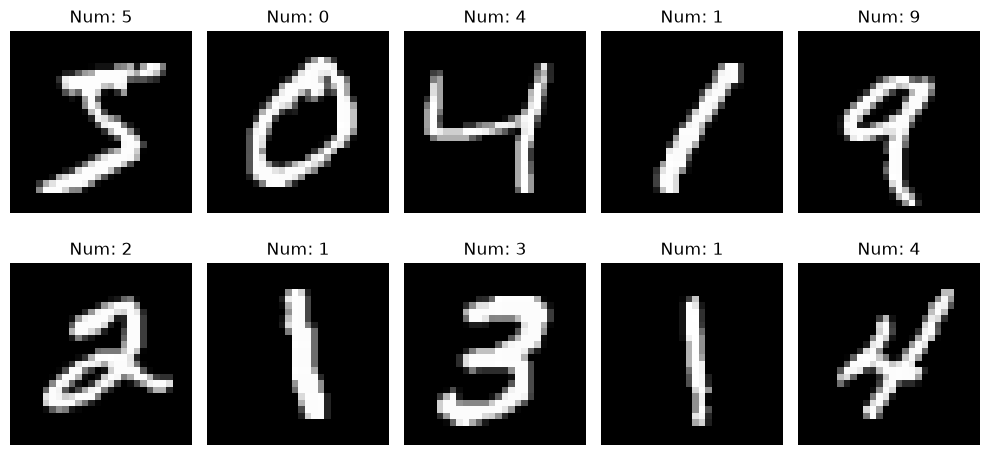

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Num: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Define the Model Architecture (Sequential API):

In [8]:

model = keras.Sequential([
	# Flatten 28x28 image to 784-element vector
	keras.Input(shape=(28, 28)),
	layers.Flatten(),

	# Hidden Layer 1: 128 neurons, ReLU activation
	layers.Dense(128, activation="relu"),

	# Output Layer: 10 neurons, Softmax activation
	layers.Dense(10, activation="softmax")
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile the Model:

In [10]:
model.compile(
	optimizer="adam",
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"]
)

### 5. Train the Model (the \texttt{fit} function):

In [11]:
history = model.fit(
		x_train,
		y_train,
		epochs=5,
		batch_size=32,
		validation_split=0.2,
        verbose=2
)

Epoch 1/5


1500/1500 - 2s - 2ms/step - accuracy: 0.9185 - loss: 0.2876 - val_accuracy: 0.9539 - val_loss: 0.1559


Epoch 2/5


1500/1500 - 2s - 1ms/step - accuracy: 0.9625 - loss: 0.1280 - val_accuracy: 0.9642 - val_loss: 0.1188


Epoch 3/5


1500/1500 - 2s - 1ms/step - accuracy: 0.9743 - loss: 0.0864 - val_accuracy: 0.9673 - val_loss: 0.1062


Epoch 4/5


1500/1500 - 2s - 1ms/step - accuracy: 0.9820 - loss: 0.0627 - val_accuracy: 0.9701 - val_loss: 0.1006


Epoch 5/5


1500/1500 - 2s - 1ms/step - accuracy: 0.9874 - loss: 0.0459 - val_accuracy: 0.9722 - val_loss: 0.0968


### 6. Evaluate the Model:

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc}")

313/313 - 0s - 1ms/step - accuracy: 0.9721 - loss: 0.0953



Test accuracy: 0.972100019454956


### 7. Plot Training History:

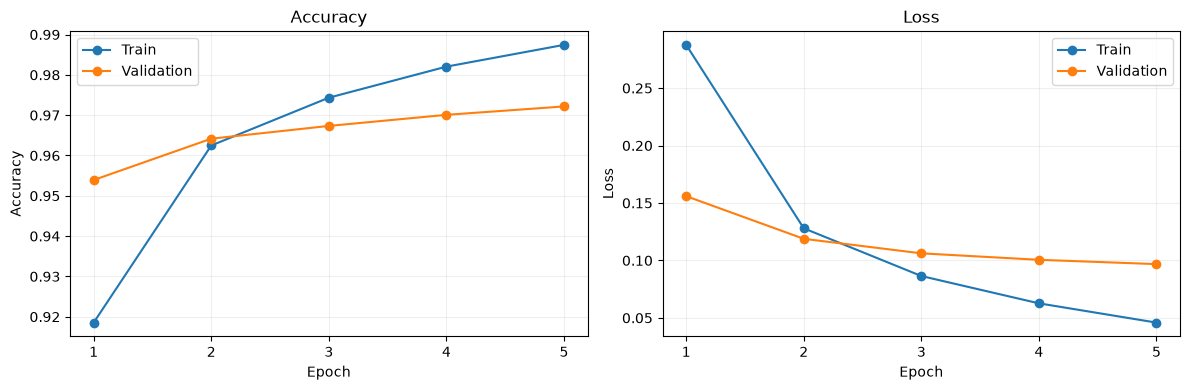

In [13]:
epochs = range(1, len(history.history["accuracy"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(epochs, history.history[metric], "o-", label="Train")
    ax.plot(epochs, history.history["val_" + metric], "o-", label="Validation")
    ax.set(title=title, xlabel="Epoch", ylabel=title, xticks=list(epochs))
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 8. Detailed Evaluation: Confusion Matrix and Classification Report

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(x_test, verbose=0)
# Convert predictions from probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=range(10), digits=4))


Confusion Matrix:
[[ 971    1    0    2    1    1    2    1    1    0]
 [   0 1125    1    1    0    1    3    1    3    0]
 [  12    3  991    6    1    0    5    7    7    0]
 [   1    0    1  998    0    3    0    2    1    4]
 [   4    0    2    1  952    0    4    3    2   14]
 [   4    1    0   17    0  843   16    1    4    6]
 [   4    2    0    1    3    3  945    0    0    0]
 [   3    4    6    9    0    0    0  992    1   13]
 [   7    2    3   18    3    2    5    5  926    3]
 [   4    6    0   10    5    2    1    3    0  978]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9614    0.9908    0.9759       980
           1     0.9834    0.9912    0.9873      1135
           2     0.9871    0.9603    0.9735      1032
           3     0.9389    0.9881    0.9629      1010
           4     0.9865    0.9695    0.9779       982
           5     0.9860    0.9451    0.9651       892
           6     0.9633    0.9864    0.9747    

In [15]:
cm = confusion_matrix(y_test, y_pred)


**prompt:** plot confusion matrix

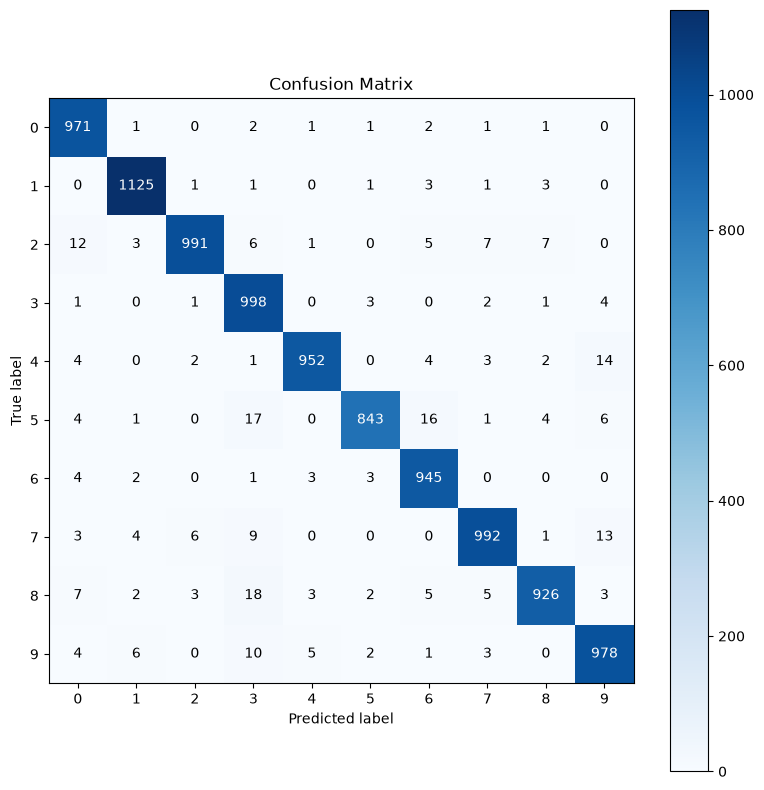

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(cm.shape[0])
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Annotate each cell with the count
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

### View Mnist Data

**prompt:** plot mnist data

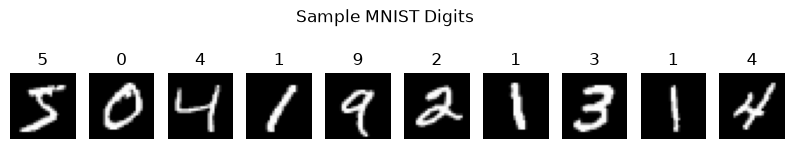

In [17]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

**prompt:** plot x_test and print predicted results

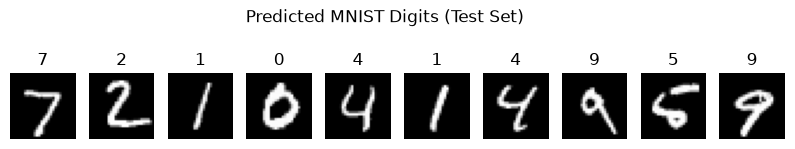

Predicted labels for first 10 test images: [7 2 1 0 4 1 4 9 5 9]


In [18]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(str(y_pred[i]))
    plt.axis('off')
plt.suptitle('Predicted MNIST Digits (Test Set)')
plt.show()
print("Predicted labels for first 10 test images:", y_pred[:10])

## Save Model

In [19]:
MODEL_PATH = LAB_DIR / "67102010164_mnist_model.keras"
model.save(MODEL_PATH)
print("Saved:", MODEL_PATH.name, "—", MODEL_PATH.stat().st_size, "bytes")

Saved: 67102010164_mnist_model.keras — 1244504 bytes


## Clear session and reload the saved model

The next cells discard the trained model object and load the `.keras` file for inference.

## Load Model, Read Image and Predict

https://www.kaggle.com/datasets/scolianni/mnistasjpg

In [20]:
del model
keras.backend.clear_session()

In [21]:
model = keras.models.load_model("67102010164_mnist_model.keras")
print("Reloaded:", MODEL_PATH.name)
reloaded_predictions = model.predict(x_test[:32], verbose=0)
np.testing.assert_allclose(reloaded_predictions, predictions[:32], rtol=1e-5, atol=1e-6)
print("Reload verification: first 32 predictions match the trained model.")

Reloaded: 67102010164_mnist_model.keras
Reload verification: first 32 predictions match the trained model.


Input shape: (1, 28, 28)
Predicted digit: 2
Confidence: 100.00%


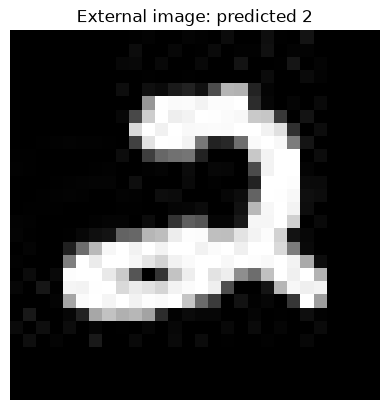

In [22]:
from PIL import Image

with Image.open("img_1.jpg") as source_image:
    img = source_image.convert("L").resize((28, 28))
img_array = np.asarray(img, dtype="float32")[None, ...] / 255.0
prediction = model.predict(img_array, verbose=0)[0]
predicted_digit = int(np.argmax(prediction))
print("Input shape:", img_array.shape)
print("Predicted digit:", predicted_digit)
print(f"Confidence: {prediction[predicted_digit]:.2%}")
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title(f"External image: predicted {predicted_digit}")
plt.axis("off")
plt.show()

In [23]:
import json
metrics = {
    "seed": 164, "epochs": 5, "batch_size": 32, "validation_split": 0.2,
    "test_loss": float(test_loss), "test_accuracy": float(test_acc),
    "external_image_prediction": predicted_digit,
    "external_image_confidence": float(prediction[predicted_digit]),
    "tensorflow": tf.__version__, "keras": keras.__version__,
    "history": {k: [float(v) for v in values] for k, values in history.history.items()}
}
Path("metrics.json").write_text(json.dumps(metrics, indent=2))
print(f"Test accuracy: {test_acc:.2%} on {len(y_test):,} held-out images.")
print("Training uses 48,000 images; validation uses 12,000 separate training-set images.")

Test accuracy: 97.21% on 10,000 held-out images.
Training uses 48,000 images; validation uses 12,000 separate training-set images.


## Streamlit application

The application uses the saved model and the same grayscale, resize, and normalization pipeline. Optional inversion supports dark digits on a light background.

In [24]:
print(Path("app.py").read_text())

from pathlib import Path

import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image, UnidentifiedImageError


MODEL_FILENAME = "67102010164_mnist_model.keras"
MODEL_PATH = Path(__file__).resolve().parent / MODEL_FILENAME
CLASS_NAMES = [str(digit) for digit in range(10)]


st.set_page_config(
    page_title="MNIST Digit Recognizer",
    page_icon="✍️",
    layout="centered",
)

st.markdown(
    """
    <style>
        .block-container {max-width: 780px; padding-top: 2.5rem;}
        [data-testid="stMetricValue"] {color: #5b4bdb;}
        .subtitle {color: #667085; margin-top: -0.75rem; margin-bottom: 1.75rem;}
    </style>
    """,
    unsafe_allow_html=True,
)


@st.cache_resource(show_spinner=False)
def load_model(model_path: str) -> tf.keras.Model:
    """Load the trained Keras model once per Streamlit process."""
    return tf.keras.models.load_model(model_path)


def preprocess_image(image: Image.Image, invert: bool = False) -> tuple[np.ndarray, Image.

In [25]:
print(Path("requirements.txt").read_text())

tensorflow==2.16.1
streamlit>=1.33,<2.0
Pillow>=10.3,<12.0
numpy>=1.26,<2.0



In [26]:
print("Python:", sys.version.split()[0])

Python: 3.12.9


## Deployment

Deploy the repository on https://share.streamlit.io using branch `main`, entry point `app.py`, and Python 3.12. The repository contains the model and pinned application dependencies. Test the public app with `img_1.jpg` and compare its result to the notebook. The app link is recorded at the top of this notebook.

## Interpretation

The test set is reserved for final evaluation. Validation accuracy and loss help identify overfitting during training. Each confusion-matrix row is the true digit and each column is the predicted digit. Errors away from the diagonal show which digits the network confuses.

The softmax score describes the model output and is not a guarantee of correctness. This model is trained on centered MNIST handwriting; photographs with clutter, multiple digits, or unusual backgrounds can perform poorly.

In [27]:
assert MODEL_PATH.is_file()
assert cm.shape == (10, 10) and cm.sum() == 10000
print("Notebook checks passed.")

Notebook checks passed.
